In [1]:
import os
import glob
from concurrent.futures import ProcessPoolExecutor
import subprocess
import pandas as pd
import numpy as np

# calculate motif

In [2]:

# 定义HOMER和基因组路径
HOMER_FINDMOTIFSGENOME = '/cluster2/huanglab/jiamao/Apps/HOMER/bin/findMotifsGenome.pl'
GENOME = 'hg38' # hg38, mm10
BACKGROUND = '/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/Homer/HSC/shuffle.bed'
#SIZE = '500'

# 定义输入和输出路径
path_in = '/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/Homer/HSC/bed/'
path_out = '/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/Homer/HSC/out/'

# 获取所有输入文件
file_ins = sorted(glob.glob(path_in + '*.bed'))
file_ins

['/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/Homer/HSC/bed/AST.bed',
 '/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/Homer/HSC/bed/COP.bed',
 '/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/Homer/HSC/bed/Ependymal.bed',
 '/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/Homer/HSC/bed/ExN_immature_1.bed',
 '/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/Homer/HSC/bed/ExN_immature_2.bed',
 '/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/Homer/HSC/bed/ExN_immature_3.bed',
 '/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/Homer/HSC/bed/ExN_mature_1.bed',
 '/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/Homer/HSC/bed/ExN_mature_2.bed',
 '/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/Homer/HSC/bed/ExN_mature_3.bed',
 '/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/Homer/HSC/bed/ExN_naive.bed',
 '/cluster2/huanglab/jiamao/Project/Hu

In [163]:
# 定义一个函数来处理每个文件
def process_file(file_in):
    file_name = os.path.basename(file_in)
    output_dir = os.path.join(path_out, os.path.splitext(file_name)[0])
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
    cmd = HOMER_FINDMOTIFSGENOME + ' ' + file_in \
                                    + ' ' + GENOME \
                                    + ' ' + output_dir \
                                    + ' -bg ' + BACKGROUND \
                                    + ' -size given'# + SIZE 
#                                    \
#                                    + ' -mask' #mask会减少计算peak数和背景数，得到一个可能的motif之后，在后续的motif分析中是否排除该motif的影响
    try:
        subprocess.run(cmd, shell=True)
    except subprocess.CalledProcessError as e:
        print(f"An error occurred while processing {file_in}: {e}")


In [ ]:
# 获取CPU核心数
import multiprocessing
cpu_cores = 8

# 使用ProcessPoolExecutor来并行处理文件
with ProcessPoolExecutor(max_workers=cpu_cores) as executor:
    executor.map(process_file, file_ins)

In [ ]:
import multiprocessing
cpu_cores = multiprocessing.cpu_count()
cpu_cores 

144

In [8]:
import os
import shutil

# 定义输入和输出路径
path_out = '/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/Homer/HSC/out/'
summary_path = '/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/Homer/HSC/out/summary/'

# 确保summary目录存在
if not os.path.exists(summary_path):
    os.makedirs(summary_path)

# 遍历path_out目录下的所有子文件夹
for subdir, dirs, files in os.walk(path_out):
    for file in files:
        if file == 'knownResults.html':
            # 构建源文件路径
            src_file = os.path.join(subdir, file)
            # 构建目标文件路径，包括新的文件名
            dst_file = os.path.join(summary_path, 'knownResults_' + os.path.basename(subdir) + '.html')
            # 复制文件
            shutil.copy(src_file, dst_file)
            print(f"Copied {src_file} to {dst_file}")

print("All knownResults.html files have been copied and renamed.")

Copied /cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/Homer/HSC/out/ExN_immature_2/knownResults.html to /cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/Homer/HSC/out/summary/knownResults_ExN_immature_2.html
Copied /cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/Homer/HSC/out/AST/knownResults.html to /cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/Homer/HSC/out/summary/knownResults_AST.html
Copied /cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/Homer/HSC/out/Ependymal/knownResults.html to /cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/Homer/HSC/out/summary/knownResults_Ependymal.html
Copied /cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/Homer/HSC/out/ExN_immature_1/knownResults.html to /cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/Homer/HSC/out/summary/knownResults_ExN_immature_1.html
Copied /cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/Homer/HSC/

# Plot

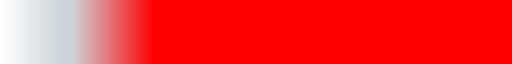

In [2]:
import matplotlib.colors as mcolors
from matplotlib.colors import ListedColormap

def colorRamp2(colors, positions):
    cmap = mcolors.LinearSegmentedColormap.from_list('custom_cmap', list(zip(positions, colors)))
    return cmap

# Specify colors and their positions (0 to 1)
positions = [0, 0.12, 0.14, 0.3, 1]  # Adjust position to shift purple leftward
colors = ['white', '#ced4da', '#ced4da', 'red', 'red']

# Generate the custom colormap
my_custom_colormap = colorRamp2(colors, positions)
my_custom_colormap

In [3]:
# summary stats
# 定义目录和文件路径
path_out = '/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/Homer/HSC/out/'

# 子文件夹列表/组列表
subfolders = [
    "NPC_proliferative", "NPC", "IPC", "ExN_naive", "ExN_immature_1", "ExN_immature_2", "ExN_immature_3", "ExN_mature_1", "ExN_mature_2", "ExN_mature_3", "ExN_ventral",
    "InN_naive", "InN_immature_1", "InN_immature_2", "InN_mature_1", "InN_mature_2", "InN_ventral_1", "InN_ventral_2", "InN_ventral_3",
      "MN1", "MN2", 
      "APC_cycling", "APC_dorsal", "APC_ventral", "AST",
      "OPC", "COP", "MFOL", "MOL", 
      "RP", "MP", "FP",
      "Schwann", "EC", "VLMC", "PC", "Microglia"
    ]

# 空列表
dfs = []

# 遍历
for subfolder in subfolders:
    # 构建knownResults.txt的完整路径
    known_results_path = os.path.join(path_out, subfolder, 'knownResults.txt')
    
    # 检查文件是否存在
    if os.path.exists(known_results_path):
        # 读取文件
        df = pd.read_csv(known_results_path, sep='\t', usecols=['Motif Name', 'P-value'])
        
        # 只取motif的简名
        df['Motif Name'] = df['Motif Name'].apply(lambda x: x.split('(')[0].strip())

        # 添加group列便于区分
        df['group'] = subfolder
        
        # 汇总
        dfs.append(df)

# 合并
df_all = pd.concat(dfs, ignore_index=True)



In [4]:
df_all

,Motif Name,P-value,group
0,Sox3,1.000000e-291,NPC_proliferative
1,Sox21,1.000000e-263,NPC_proliferative
2,Sox2,1.000000e-263,NPC_proliferative
3,SOX1,1.000000e-219,NPC_proliferative
4,Sox10,1.000000e-216,NPC_proliferative
...,...,...,...
17459,THRa,1.000000e+00,Microglia
17460,ZEB1,1.000000e+00,Microglia
17461,ZEB2,1.000000e+00,Microglia
17462,ZNF136,1.000000e+00,Microglia


In [5]:
print((df_all['P-value'] == 0).sum()) # 查看有多少个 P-value 为 0

745


In [6]:
df_all['P-value'] = df_all['P-value'].astype(float)
min_nonzero_p = df_all.loc[df_all['P-value'] > 0, 'P-value'].min()

# 这样计算 -log10 时就不会得到 inf
df_all['P-value_fixed'] = df_all['P-value'].replace(0, min_nonzero_p if min_nonzero_p > 0 else 1e-300)

# 计算-log10(P value)
df_all['-log10(P value)'] = -np.log10(df_all['P-value_fixed'])
df_all['-log10(P value)'] = df_all['-log10(P value)'].astype(int)

In [7]:
df_all

,Motif Name,P-value,group,P-value_fixed,-log10(P value)
0,Sox3,1.000000e-291,NPC_proliferative,1.000000e-291,291
1,Sox21,1.000000e-263,NPC_proliferative,1.000000e-263,263
2,Sox2,1.000000e-263,NPC_proliferative,1.000000e-263,263
3,SOX1,1.000000e-219,NPC_proliferative,1.000000e-219,219
4,Sox10,1.000000e-216,NPC_proliferative,1.000000e-216,216
...,...,...,...,...,...
17459,THRa,1.000000e+00,Microglia,1.000000e+00,0
17460,ZEB1,1.000000e+00,Microglia,1.000000e+00,0
17461,ZEB2,1.000000e+00,Microglia,1.000000e+00,0
17462,ZNF136,1.000000e+00,Microglia,1.000000e+00,0


In [8]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 数据透视
# 如果同一个 Motif 在同一个 group 出现了多次（通常是因为 Homer 库里有同名不同来源的 motif），我们取最大值
df_pivot = df_all.pivot_table(index='Motif Name', 
                             columns='group', 
                             values='-log10(P value)', 
                             aggfunc='max')

# 2. 填充缺失值
# 有些 Motif 在某些 group 中可能完全没被检测到，填充为 0
df_pivot = df_pivot.fillna(0)

# 按照给出的 subfolders 顺序对列进行排序（保持发育谱系的逻辑）
df_pivot = df_pivot[subfolders]

In [9]:
# 筛选逻辑：在至少一个 group 中进入了 Top x 的 motif，或者总方差最大的前 50 个
top_n = 10
selected_motifs = set()

for col in df_pivot.columns:
    # 选出每个列（group）中值最大的前 N 个 motif 名
    top_motifs = df_pivot[col].nlargest(top_n).index.tolist()
    selected_motifs.update(top_motifs)

# 过滤矩阵
df_heatmap = df_pivot.loc[list(selected_motifs)]

# # 如果 Motif 还是太多，可以按行方差再排个序，取前 100 个
# if len(df_heatmap) > 100:
#     df_heatmap = df_heatmap.loc[df_heatmap.var(axis=1).nlargest(100).index]

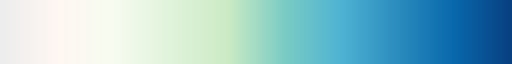

In [10]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.colors import LinearSegmentedColormap

ATAC_colors = ["#3361A5", "#2C72C5", "#2683E6", "#1F94F6", "#19A6FB", "#20B5FD", "#51C1F6", "#81CCEF", "#9CD0E8", "#B4D3E0", "#C9D4CD", "#DAD3B0", "#EBD190", "#F3C35B", "#FBB627", "#F5871F", "#EA4E25", "#D92727", "#BE2222", "#A31D1D"]
ATAC_cmap = LinearSegmentedColormap.from_list("my_cmap", ATAC_colors, N=256)
ATAC_cmap
exp_colors = ["#EDEDED", "#FFF7F3","#F7FCF0","#E0F3DB","#CCEBC5","#7BCCC4","#4EB3D3","#2B8CBE","#0868AC","#084081"]
exp_cmap = LinearSegmentedColormap.from_list("my_cmap", exp_colors, N=256)
exp_cmap

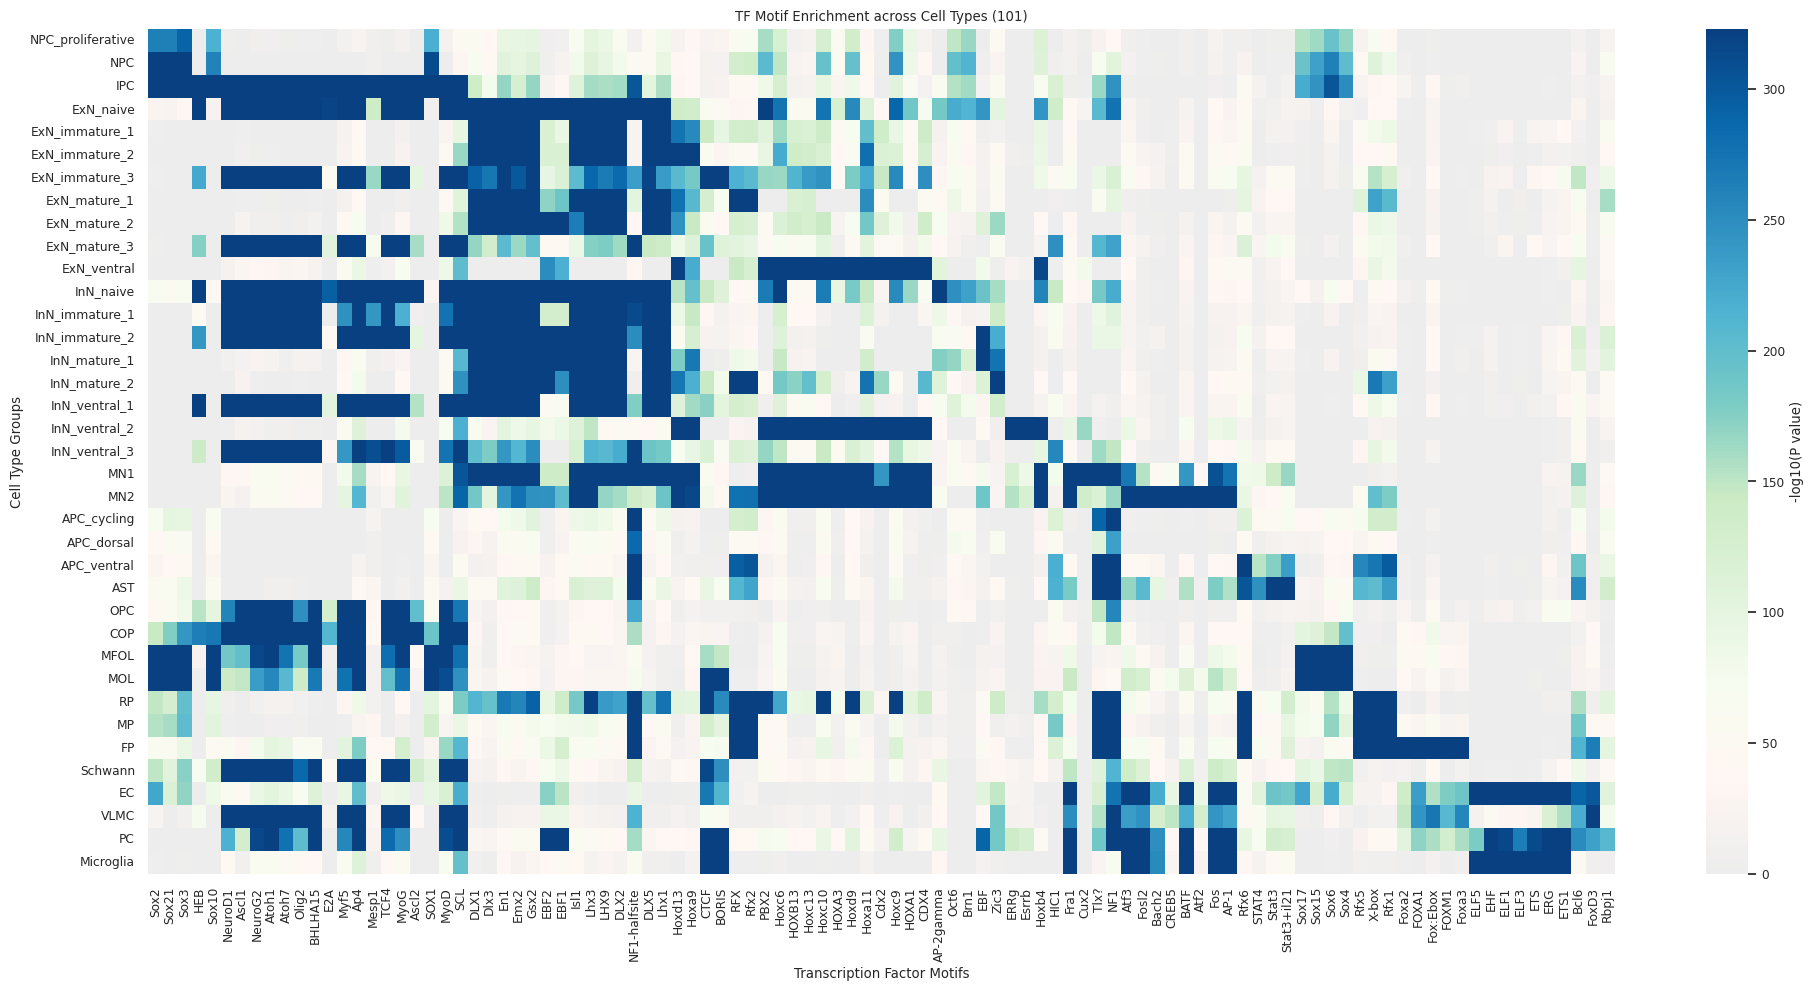

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 假设 df_heatmap 是你之前的矩阵（Index是Motif, Columns是Group）

# 1. 转置矩阵：行变成细胞类型，列变成 Motif
df_t = df_heatmap.T

# 2. 确保行顺序按照 subfolders 列表排列
# 过滤掉矩阵中可能不存在的 group，防止报错
ordered_groups = [g for g in subfolders if g in df_t.index]
df_t = df_t.reindex(ordered_groups)

# 3. 核心步骤：对 Motif（列）进行排序以产生对角线趋势
# 逻辑：找到每个 Motif 达到最大值（-log10P最大）的行索引位置
def get_peak_index(column):
    # 返回最大值所在的行号（0, 1, 2...）
    return np.argmax(column.values)

# 计算每个 Motif 的 Peak 位置
motif_peak_pos = df_t.apply(get_peak_index)

# 根据 Peak 位置对列进行排序
# 如果 Peak 位置相同，可以再按该位置的数值大小降序排
sorted_motifs = motif_peak_pos.sort_values().index
df_final = df_t[sorted_motifs]

# 4. 绘图
plt.figure(figsize=(20, 10)) # 宽屏布局更适合横向显示大量 Motif
sns.set(font_scale=0.8)

# 使用 heatmap 而不是 clustermap，因为已经手动排好序了
# 如果想用 clustermap，记得设置 row_cluster=False, col_cluster=False
ax = sns.heatmap(df_final, 
                 cmap=exp_cmap,    # "rocket_r", "OrRd"
                 annot=False, 
                 cbar_kws={'label': '-log10(P value)'},
                 xticklabels=True, 
                 yticklabels=True)

plt.title('TF Motif Enrichment across Cell Types (101)')
plt.xlabel('Transcription Factor Motifs')
plt.ylabel('Cell Type Groups')
plt.xticks(rotation=90) # Motif 名字旋转90度
plt.tight_layout()
plt.savefig("motif_enrich.pdf", dpi=300, bbox_inches='tight', transparent=True)
plt.show()

In [12]:
df_final

Motif Name,Sox2,Sox21,Sox3,HEB,Sox10,NeuroD1,Ascl1,NeuroG2,Atoh1,Atoh7,...,ELF5,EHF,ELF1,ELF3,ETS,ERG,ETS1,Bcl6,FoxD3,Rbpj1
group,,,,,,,,,,,,,,,,,,,,,
NPC_proliferative,263,263,291,0,216,3,1,8,6,3,...,0,0,0,0,0,0,2,12,0,21
NPC,323,323,323,0,260,0,0,0,0,0,...,0,0,0,0,0,0,1,22,1,66
IPC,323,323,323,323,323,323,323,323,323,323,...,0,1,0,0,0,4,2,12,6,19
ExN_naive,27,21,32,323,20,323,323,323,323,323,...,0,0,0,0,0,1,0,26,1,15
ExN_immature_1,5,0,2,0,2,0,4,1,0,1,...,4,8,23,3,23,25,36,12,2,62
ExN_immature_2,1,0,0,0,0,0,6,3,5,2,...,0,3,6,0,4,12,13,7,0,38
ExN_immature_3,4,0,2,224,0,323,323,323,323,323,...,2,20,23,2,31,38,75,148,6,87
ExN_mature_1,0,0,0,0,0,0,4,5,3,1,...,3,14,2,7,1,18,26,73,2,160
ExN_mature_2,0,0,0,0,0,2,18,10,9,5,...,3,11,5,3,5,22,26,46,3,66


In [14]:
df_final.to_csv("motif_enrich.csv", index=True, header=True)